In [37]:
import pandas as pd
import numpy as np
from pathlib import Path


In [38]:
df = pd.read_csv('/test_dataaa.csv')

In [39]:
df.head(20)

,user_id,event_name,ad_ilrd,purchase_value,Event_timestamp,Event_date
0,00D2183276604A2E81814C7A0E39BC3F,session_start,0.000000,0,12:00:15 AM,2/25/2025
1,00D2183276604A2E81814C7A0E39BC3F,session_info,0.000000,0,12:00:38 AM,2/25/2025
2,d7a8a4a685d17ab241795ba412778fb3,session_start,0.000000,0,12:02:07 AM,2/25/2025
3,00D2183276604A2E81814C7A0E39BC3F,advert_completed,0.126466,0,12:02:35 AM,2/25/2025
4,d7a8a4a685d17ab241795ba412778fb3,app_remove,0.000000,0,12:03:26 AM,2/25/2025
5,00D2183276604A2E81814C7A0E39BC3F,advert_completed,0.092874,0,12:05:59 AM,2/25/2025
6,d536b37c51675a06d0e7f5dd7582e27c,session_start,0.000000,0,12:07:17 AM,2/25/2025
7,d536b37c51675a06d0e7f5dd7582e27c,session_info,0.000000,0,12:07:39 AM,2/25/2025
8,d536b37c51675a06d0e7f5dd7582e27c,advert_completed,0.012228,0,12:09:20 AM,2/25/2025
9,8cc74e9598e4ab16c6f89e0d9661265c,session_start,0.000000,0,12:13:28 AM,2/25/2025


# Daily new users (DNU)

In [40]:
df['Event_date'] = pd.to_datetime(df['Event_date'])

In [41]:
df_sessions = df[df['event_name'] == 'session_start'].copy()

In [42]:
user_birthdays = df_sessions.groupby('user_id')['Event_date'].min().reset_index()
user_birthdays.columns = ['user_id', 'first_session_date']

In [43]:
dnu_final = user_birthdays.groupby('first_session_date').size().reset_index(name='DNU')

In [44]:
print(f"Total Unique New Users: {dnu_final['DNU'].sum()}")
print(dnu_final)

Total Unique New Users: 2487
  first_session_date  DNU
0         2025-02-25  396
1         2025-02-26  331
2         2025-02-27  352
3         2025-02-28  294
4         2025-03-01  296
5         2025-03-02  281
6         2025-03-03  275
7         2025-03-04  262


In [45]:
import matplotlib.pyplot as plt

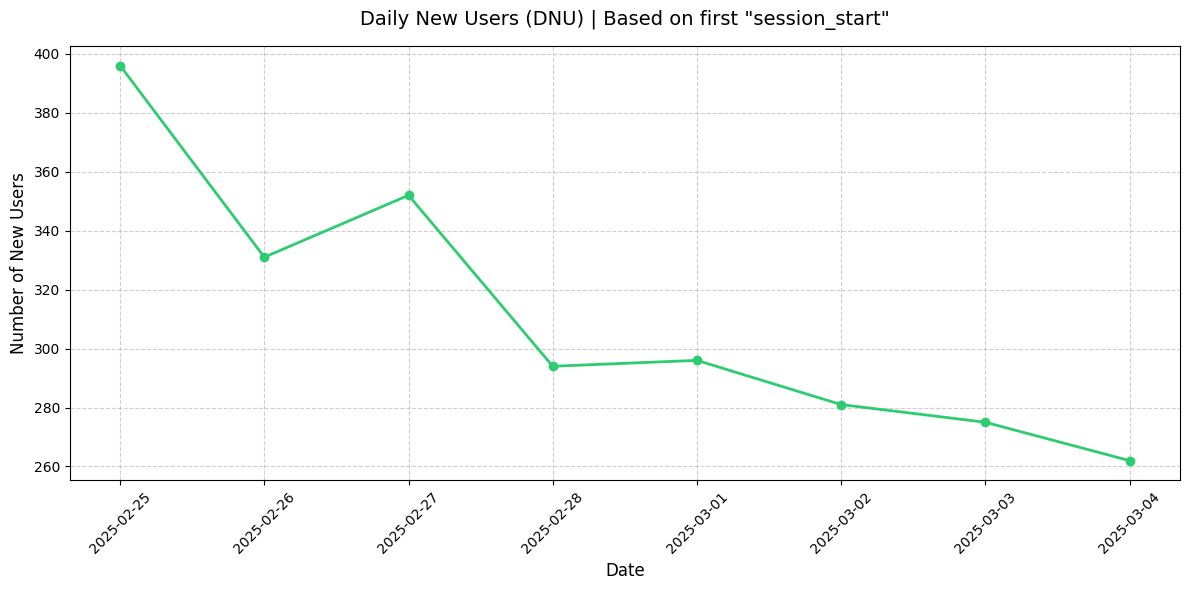

In [46]:
dnu_final = dnu_final.sort_values('first_session_date')

# Plotting
plt.figure(figsize=(12, 6))

plt.plot(dnu_final['first_session_date'], dnu_final['DNU'],
         marker='o',
         linestyle='-',
         color='#2ecc71', #green
         linewidth=2)

plt.title('Daily New Users (DNU) | Based on first "session_start"', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of New Users', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout() # labels dont get cut off

plt.show()

# Daily active users (DAU)

In [47]:
active_users = df[df['event_name'] == 'session_start'].copy()

In [48]:
active_users['Event_date'] = pd.to_datetime(active_users['Event_date'])

In [49]:
dau_df = active_users.groupby('Event_date')['user_id'].nunique().reset_index()
dau_df.columns = ['date', 'DAU']

In [50]:
au_df = dau_df.sort_values('date')

print(dau_df)

        date  DAU
0 2025-02-25  396
1 2025-02-26  507
2 2025-02-27  607
3 2025-02-28  635
4 2025-03-01  666
5 2025-03-02  737
6 2025-03-03  786
7 2025-03-04  815


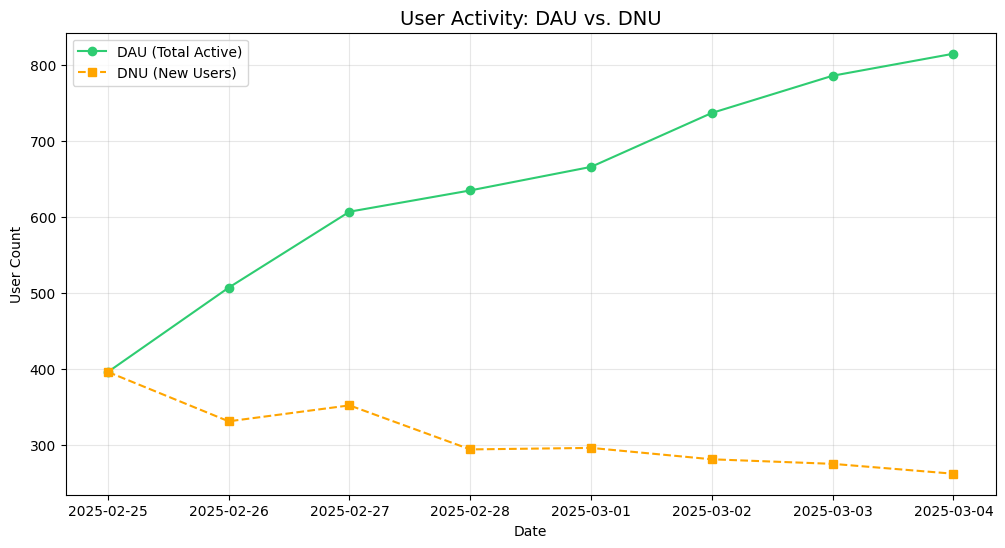

In [51]:
plt.figure(figsize=(12, 6))

# Plot DAU
plt.plot(dau_df['date'], dau_df['DAU'], label='DAU (Total Active)', marker='o', color='#2ecc71')

# Plot DNU (using the dnu_final we created earlier)
plt.plot(dnu_final['first_session_date'], dnu_final['DNU'], label='DNU (New Users)', marker='s', color='orange', linestyle='--')

plt.title('User Activity: DAU vs. DNU', fontsize=14)
plt.xlabel('Date')
plt.ylabel('User Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Daily Revenue

In [52]:
df['Event_date'] = pd.to_datetime(df['Event_date'])

In [53]:
daily_revenue = df.groupby('Event_date')['purchase_value'].sum().reset_index()
daily_revenue.columns = ['date', 'revenue']

In [54]:
print(daily_revenue)

        date  revenue
0 2025-02-25       27
1 2025-02-26      508
2 2025-02-27       12
3 2025-02-28       36
4 2025-03-01      537
5 2025-03-02      585
6 2025-03-03      107
7 2025-03-04      115


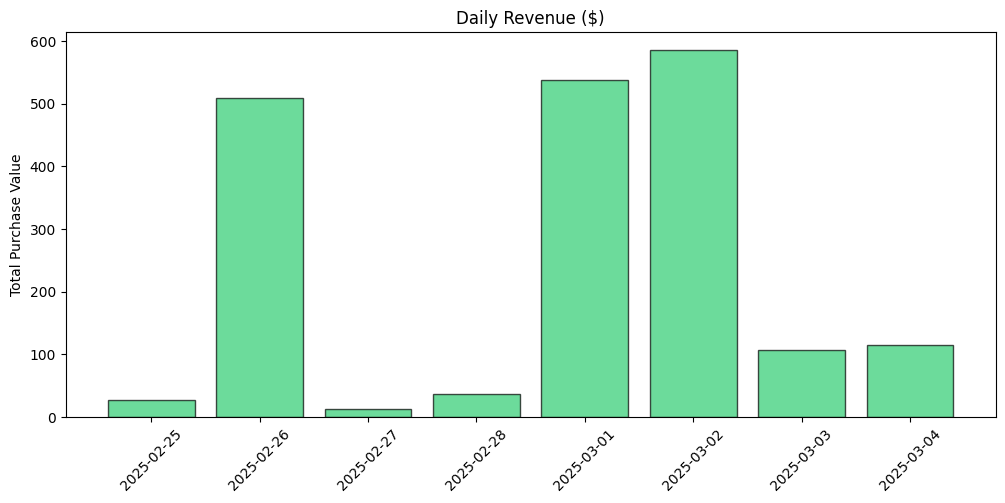

In [55]:
plt.figure(figsize=(12, 5))
plt.bar(daily_revenue['date'], daily_revenue['revenue'], color='#2ecc71', edgecolor='black', alpha=0.7)
plt.title('Daily Revenue ($)')
plt.ylabel('Total Purchase Value')
plt.xticks(rotation=45)
plt.show()

# 10-day retention

In [56]:
# 1. Identify User Birthdays (First appearance)
user_birth = df.groupby('user_id')['Event_date'].min().reset_index()
user_birth.columns = ['user_id', 'birth_date']

# 2. Merge birth date back into the original dataframe
df_retention = pd.merge(df, user_birth, on='user_id')

# 3. Calculate "Day Since Birth" for every event
df_retention['days_since_birth'] = (df_retention['Event_date'] - df_retention['birth_date']).dt.days

# 4. Identify users active on Day 0 and Day 10
# Day 0 count (The Cohort Size)
cohort_size = user_birth.groupby('birth_date').size().reset_index(name='cohort_size')

# Day 10 count (Users who returned 10 days after their birth_date)
day_10_users = df_retention[df_retention['days_since_birth'] == 10].groupby('birth_date')['user_id'].nunique().reset_index(name='returned_day_10')

# 5. Merge and Calculate %
retention_10d = pd.merge(cohort_size, day_10_users, on='birth_date', how='left').fillna(0)
retention_10d['retention_rate_pct'] = (retention_10d['returned_day_10'] / retention_10d['cohort_size']) * 100

print(retention_10d[['birth_date', 'cohort_size', 'retention_rate_pct']])

  birth_date  cohort_size  retention_rate_pct
0 2025-02-25          396                 0.0
1 2025-02-26          331                 0.0
2 2025-02-27          352                 0.0
3 2025-02-28          294                 0.0
4 2025-03-01          296                 0.0
5 2025-03-02          281                 0.0
6 2025-03-03          275                 0.0
7 2025-03-04          262                 0.0


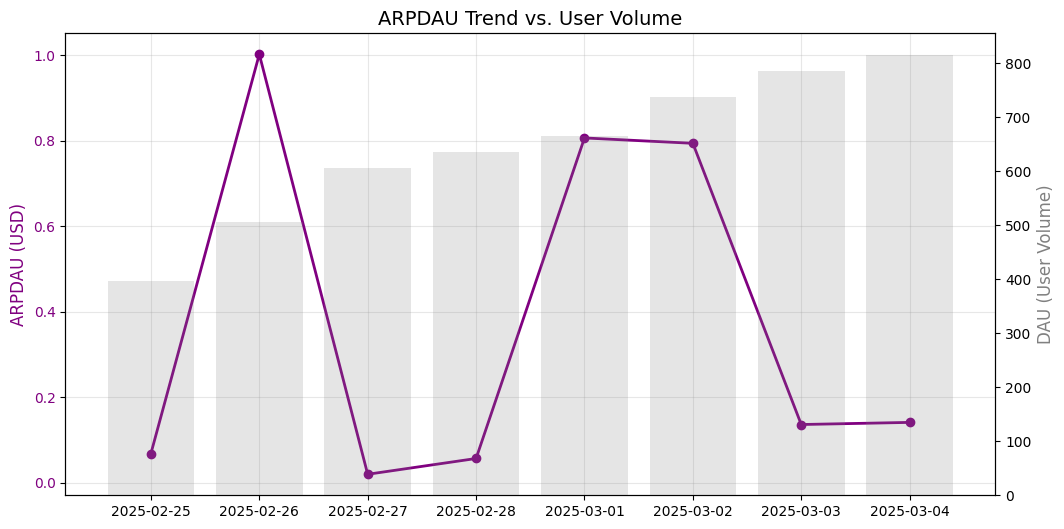

        date  revenue  DAU    ARPDAU
0 2025-02-25       27  396  0.068182
1 2025-02-26      508  507  1.001972
2 2025-02-27       12  607  0.019769
3 2025-02-28       36  635  0.056693
4 2025-03-01      537  666  0.806306
5 2025-03-02      585  737  0.793758
6 2025-03-03      107  786  0.136132
7 2025-03-04      115  815  0.141104


In [57]:
# 1. Ensure date is in datetime format
df['Event_date'] = pd.to_datetime(df['Event_date'])

# 2. Calculate Daily Revenue
daily_rev = df.groupby('Event_date')['purchase_value'].sum().reset_index()
daily_rev.columns = ['date', 'revenue']

# 3. Calculate DAU (Unique users with 'session_start' per day)
dau_counts = df[df['event_name'] == 'session_start'].groupby('Event_date')['user_id'].nunique().reset_index()
dau_counts.columns = ['date', 'DAU']

# 4. Merge Revenue and DAU data
arpdau_df = pd.merge(daily_rev, dau_counts, on='date', how='inner')

# 5. Calculate ARPDAU
# Formula: Total Revenue / Total Unique Active Users
arpdau_df['ARPDAU'] = arpdau_df['revenue'] / arpdau_df['DAU']

# 6. Visualization
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot ARPDAU as a line
ax1.plot(arpdau_df['date'], arpdau_df['ARPDAU'], color='purple', marker='o', linewidth=2, label='ARPDAU ($)')
ax1.set_ylabel('ARPDAU (USD)', color='purple', fontsize=12)
ax1.tick_params(axis='y', labelcolor='purple')

# Optional: Add DAU as a background bar to see if volume affects monetization
ax2 = ax1.twinx()
ax2.bar(arpdau_df['date'], arpdau_df['DAU'], alpha=0.2, color='gray', label='DAU')
ax2.set_ylabel('DAU (User Volume)', color='gray', fontsize=12)

plt.title('ARPDAU Trend vs. User Volume', fontsize=14)
ax1.grid(True, alpha=0.3)
plt.show()

print(arpdau_df[['date', 'revenue', 'DAU', 'ARPDAU']])

/tmp/ipykernel_16974/962617323.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=arppu_df, x='date', y='ARPPU', palette='magma')


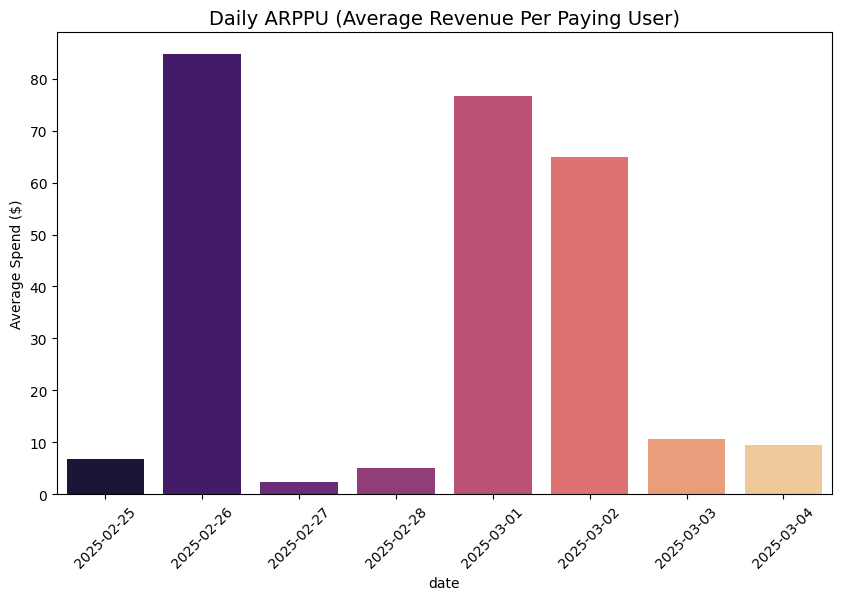

        date  total_revenue  paying_user_count      ARPPU
0 2025-02-25             27                  4   6.750000
1 2025-02-26            508                  6  84.666667
2 2025-02-27             12                  5   2.400000
3 2025-02-28             36                  7   5.142857
4 2025-03-01            537                  7  76.714286
5 2025-03-02            585                  9  65.000000
6 2025-03-03            107                 10  10.700000
7 2025-03-04            115                 12   9.583333


In [58]:
# 1. Filter for events where a purchase actually happened
paying_users_df = df[df['purchase_value'] > 0].copy()

# 2. Calculate Daily Total Revenue
daily_revenue = paying_users_df.groupby('Event_date')['purchase_value'].sum().reset_index()
daily_revenue.columns = ['date', 'total_revenue']

# 3. Calculate Daily Unique Paying Users (DPU)
daily_paying_users = paying_users_df.groupby('Event_date')['user_id'].nunique().reset_index()
daily_paying_users.columns = ['date', 'paying_user_count']

# 4. Merge and Calculate ARPPU
arppu_df = pd.merge(daily_revenue, daily_paying_users, on='date')
arppu_df['ARPPU'] = arppu_df['total_revenue'] / arppu_df['paying_user_count']

# 5. Visualizing the difference
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=arppu_df, x='date', y='ARPPU', palette='magma')
plt.title('Daily ARPPU (Average Revenue Per Paying User)', fontsize=14)
plt.ylabel('Average Spend ($)')
plt.xticks(rotation=45)
plt.show()

print(arppu_df)

In [59]:
# 1. Identify First session_start)
user_birth = df[df['event_name'] == 'session_start'].groupby('user_id')['Event_date'].min().reset_index()
user_birth.columns = ['user_id', 'birth_date']

# 2. Merge birth date into the main dataframe
ltv_df = pd.merge(df, user_birth, on='user_id')

# 3. Calculate "Age" of the user in days at the time of each purchase
ltv_df['days_since_birth'] = (pd.to_datetime(ltv_df['Event_date']) - pd.to_datetime(ltv_df['birth_date'])).dt.days

# 4. Group by birth_date and age to get revenue per cohort per day
cohort_revenue = ltv_df.groupby(['birth_date', 'days_since_birth'])['purchase_value'].sum().reset_index()

# 5. Calculating  Cumulative Revenue for each cohort
cohort_revenue['cumulative_rev'] = cohort_revenue.groupby('birth_date')['purchase_value'].cumsum()

# 6.original size of each cohort (DNU) to divide by
cohort_sizes = user_birth.groupby('birth_date').size().reset_index(name='cohort_size')

# 7. Merging and calculating Cumulative LTV
final_ltv = pd.merge(cohort_revenue, cohort_sizes, on='birth_date')
final_ltv['LTV'] = final_ltv['cumulative_rev'] / final_ltv['cohort_size']

# 8. Pivot for a clear view:
ltv_pivot = final_ltv.pivot(index='birth_date', columns='days_since_birth', values='LTV')

print("Cumulative LTV per User (Days since Join):")
print(ltv_pivot.head())

Cumulative LTV per User (Days since Join):
days_since_birth         0         1         2         3         4         5  \
birth_date                                                                     
2025-02-25        0.068182  0.141414  0.143939  0.143939  0.143939  0.143939   
2025-02-26        1.447130  1.450151  1.450151  1.450151  1.450151  1.450151   
2025-02-27        0.028409  0.068182  0.085227  0.085227  0.085227  0.113636   
2025-02-28        0.074830  0.149660  0.159864  0.163265  0.197279       NaN   
2025-03-01        1.719595  3.638514  3.864865  3.864865       NaN       NaN   

days_since_birth         6         7  
birth_date                            
2025-02-25        0.143939  0.143939  
2025-02-26        1.450151       NaN  
2025-02-27             NaN       NaN  
2025-02-28             NaN       NaN  
2025-03-01             NaN       NaN  


## Dashboard Style Visualization of Key Metrics

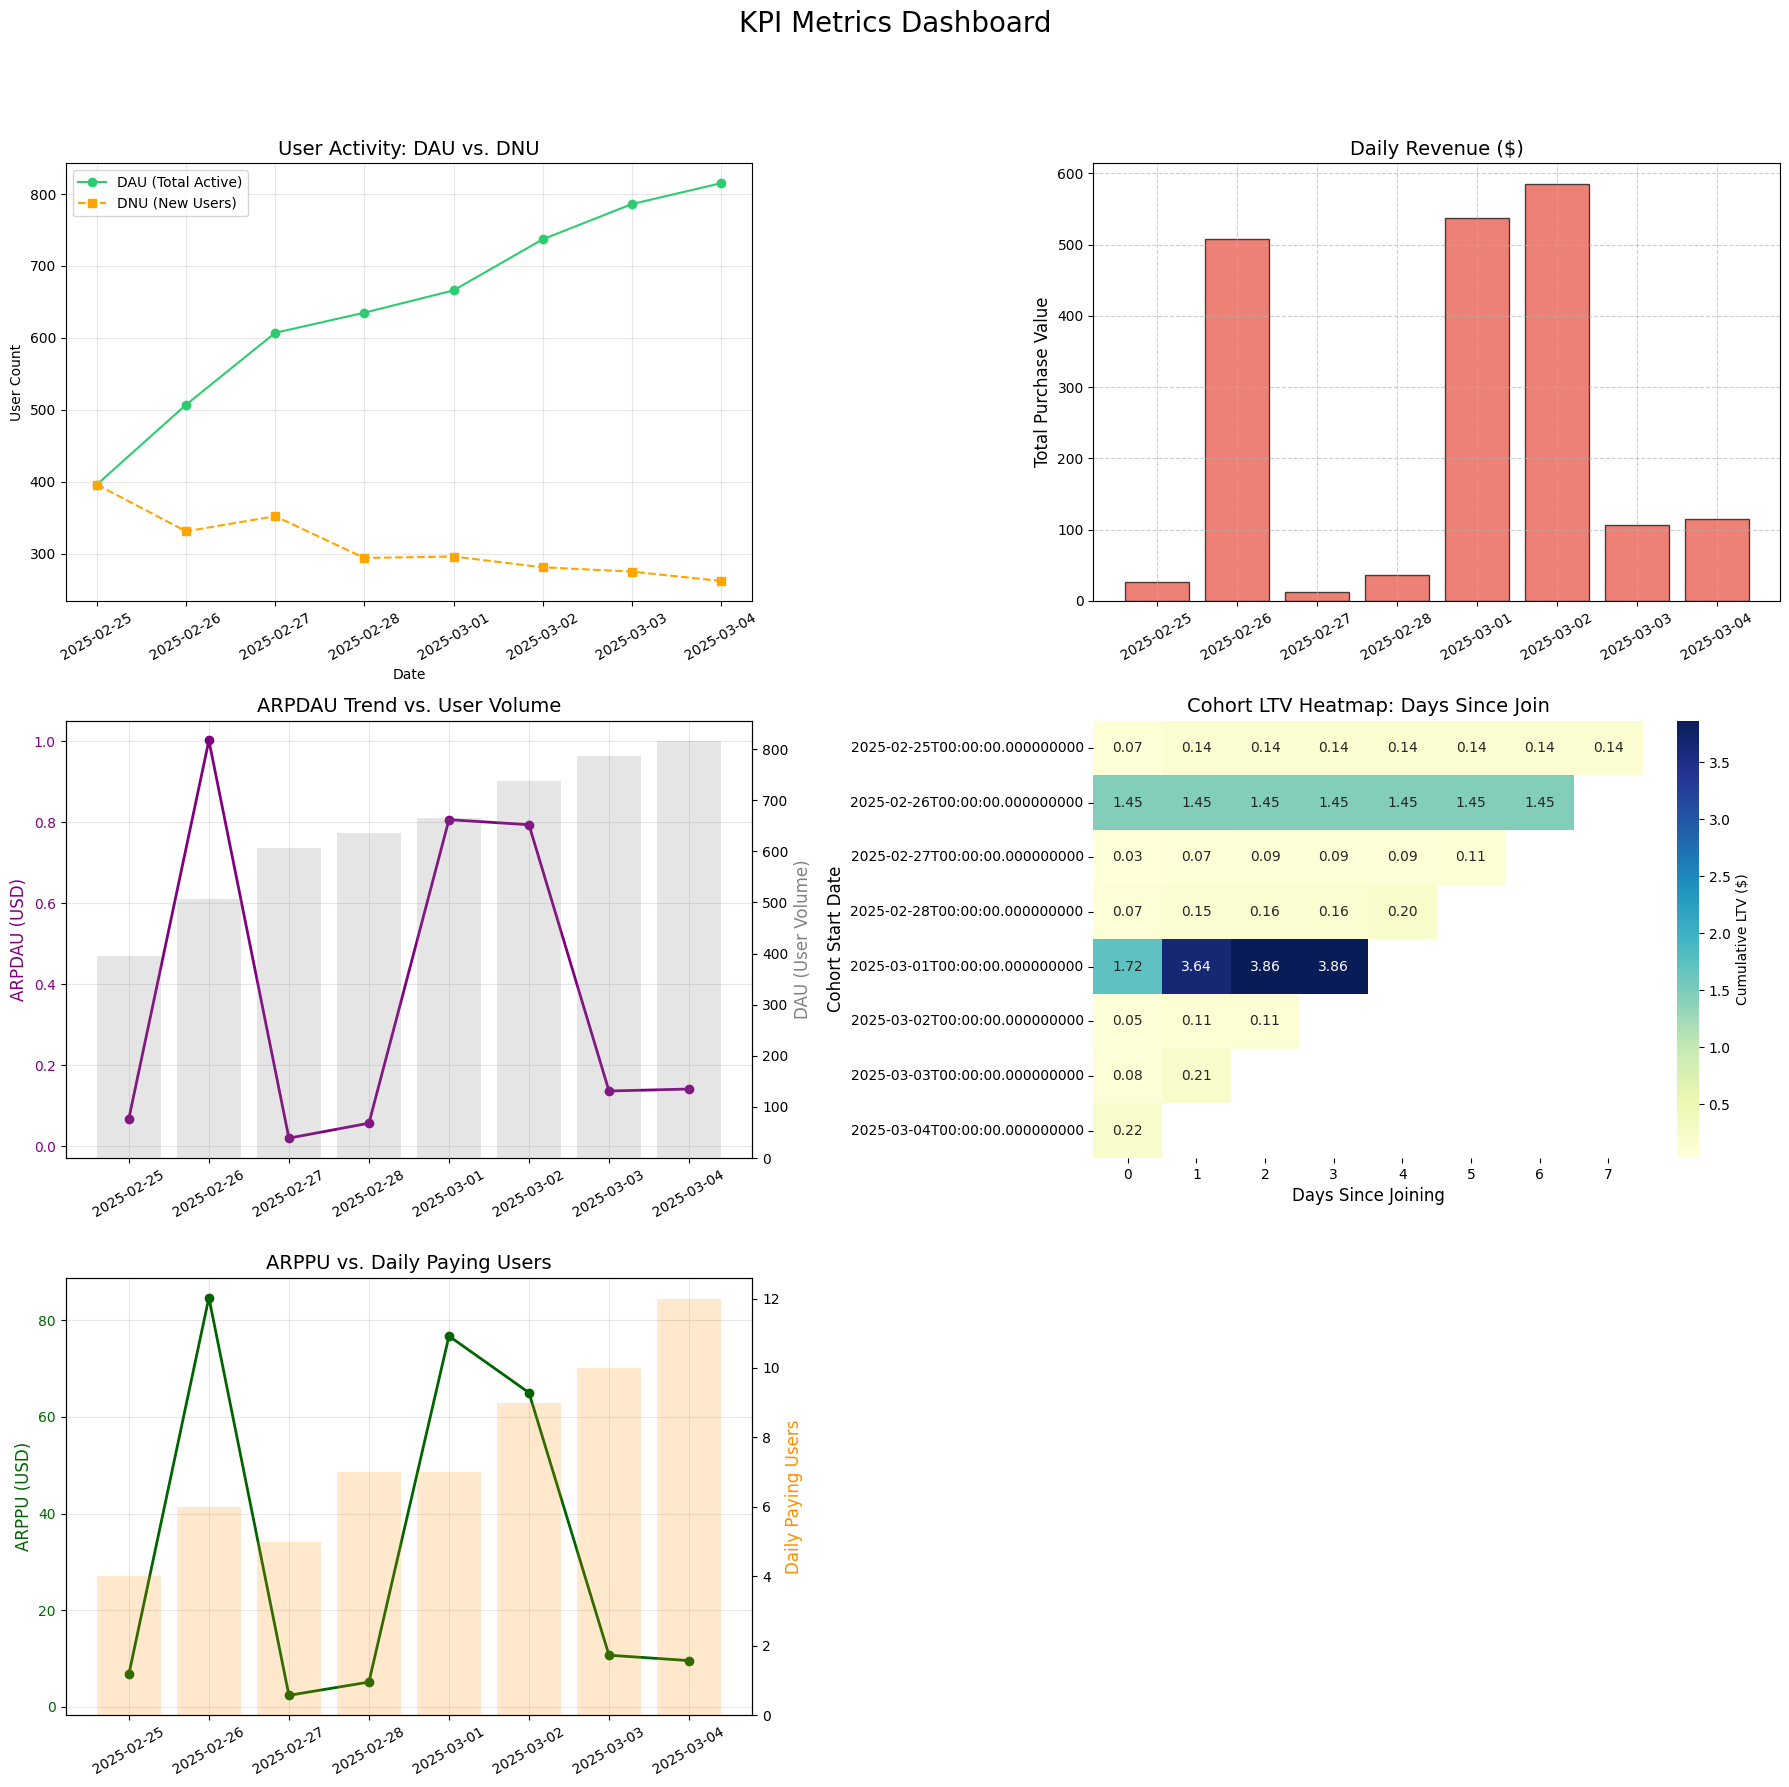

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and a set of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 18)) # Adjusted figsize for 3x2 grid
fig.suptitle('KPI Metrics Dashboard', fontsize=20, y=1.02)

# Plot 1: User Activity: DAU vs. DNU
axes[0, 0].plot(dau_df['date'], dau_df['DAU'], label='DAU (Total Active)', marker='o', color='#2ecc71')
axes[0, 0].plot(dnu_final['first_session_date'], dnu_final['DNU'], label='DNU (New Users)', marker='s', color='orange', linestyle='--')
axes[0, 0].set_title('User Activity: DAU vs. DNU', fontsize=14)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('User Count')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=30)

# Plot 2: Daily Revenue
axes[0, 1].bar(daily_revenue['date'], daily_revenue['total_revenue'], color='#e74c3c', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Daily Revenue ($)', fontsize=14)
axes[0, 1].set_ylabel('Total Purchase Value', fontsize=12)
axes[0, 1].grid(True, linestyle='--', alpha=0.6)
axes[0, 1].tick_params(axis='x', rotation=30)

# Plot 3: ARPDAU (using the twin axis plot)
ax1_arpdau = axes[1, 0]
ax1_arpdau.plot(arpdau_df['date'], arpdau_df['ARPDAU'], color='purple', marker='o', linewidth=2, label='ARPDAU ($)')
ax1_arpdau.set_ylabel('ARPDAU (USD)', color='purple', fontsize=12)
ax1_arpdau.tick_params(axis='y', labelcolor='purple')
ax1_arpdau.set_title('ARPDAU Trend vs. User Volume', fontsize=14)
ax1_arpdau.grid(True, alpha=0.3)
ax1_arpdau.tick_params(axis='x', rotation=30)

ax2_arpdau = ax1_arpdau.twinx()
ax2_arpdau.bar(arpdau_df['date'], arpdau_df['DAU'], alpha=0.2, color='gray', label='DAU')
ax2_arpdau.set_ylabel('DAU (User Volume)', color='gray', fontsize=12)


# Plot 4: Cohort LTV Heatmap
sns.heatmap(ltv_pivot, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Cumulative LTV ($)'}, ax=axes[1, 1])
axes[1, 1].set_title('Cohort LTV Heatmap: Days Since Join', fontsize=14)
axes[1, 1].set_ylabel('Cohort Start Date', fontsize=12)
axes[1, 1].set_xlabel('Days Since Joining', fontsize=12)

# Plot 5: ARPPU vs. Paying Users (Combined twin-axis plot)
ax1_arppu = axes[2, 0]
ax1_arppu.plot(arppu_df['date'], arppu_df['ARPPU'], color='darkgreen', marker='o', linewidth=2, label='ARPPU ($)')
ax1_arppu.set_ylabel('ARPPU (USD)', color='darkgreen', fontsize=12)
ax1_arppu.tick_params(axis='y', labelcolor='darkgreen')
ax1_arppu.set_title('ARPPU vs. Daily Paying Users', fontsize=14)
ax1_arppu.grid(True, alpha=0.3)
ax1_arppu.tick_params(axis='x', rotation=30)

ax2_arppu = ax1_arppu.twinx()
ax2_arppu.bar(daily_paying_users['date'], daily_paying_users['paying_user_count'], alpha=0.2, color='darkorange', label='Paying Users')
ax2_arppu.set_ylabel('Daily Paying Users', color='darkorange', fontsize=12)

# Hide the unused subplot
axes[2, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap, leaving space for suptitle
plt.show()

# Save the figure to a file
fig.savefig('kpi_dashboard.png')

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
# import seaborn as sns

# plt.figure(figsize=(12, 8))
# sns.heatmap(ltv_pivot, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Cumulative LTV ($)'})
# plt.title('Cohort LTV Heatmap: Days Since Join', fontsize=15)
# plt.ylabel('Cohort Start Date')
# plt.xlabel('Days Since Joining')
# plt.show()